dyngen绘制指标

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = '../clusters/dyngen.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [4]:
save_dir = '../figures/dyngen/standard'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [4]:
data = 'dyngen/standard-dataset_modified'

绘制CBDir

In [5]:
metric_name = 'cbdir'
basis = 'umap'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges: 
    cluster = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if cluster in metric.keys():
            if model == 'deepvelo_cui':
                model = 'deepvelo(cui)'
            result[model] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if cluster in stt_metric.keys():
                result['stt(vj)'] = stt_metric[cluster]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if cluster in ltv_metric.keys():
                result['latentvelo(lt)'] = ltv_metric[cluster]
    results[cluster] = result

results
- edge e.g. (cluster A -> cluster B)
    - model [val1, val2, ...]

In [11]:
results['sA->sB -> sB->sBmid']['scvelo'][0]

0.028048943506809615

In [38]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
edge_color_map = dict(zip(results.keys(), colors))

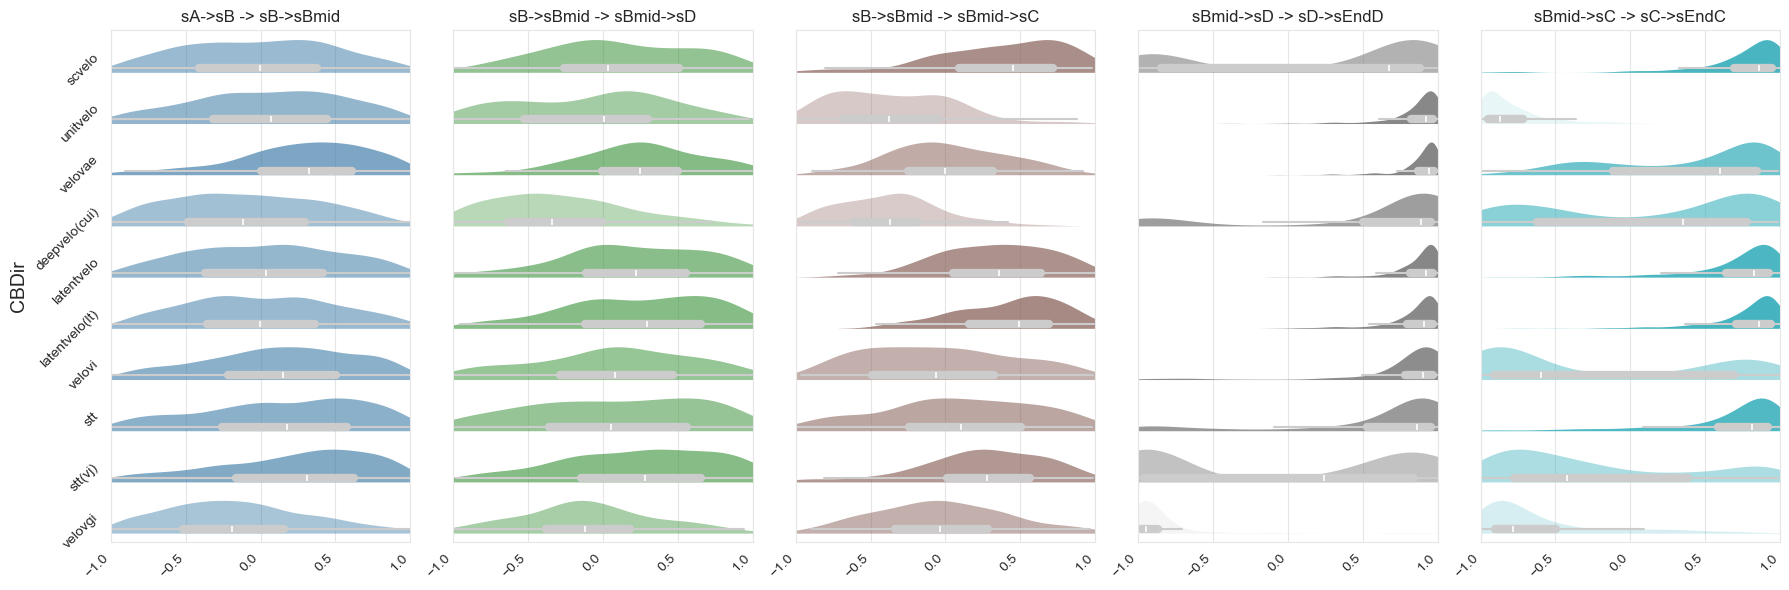

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[cluster], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='count', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    axs[i].set_title(cluster)
    axs[i].set_xlim(-1, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('CBDir', fontsize=14)
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制ICCoh

In [40]:
data = 'dyngen/standard-dataset_modified'
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if model == 'deepvelo_cui':
            model = 'deepvelo(cui)'
        result[model] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result['latentvelo(lt)'] = ltv_metric[cluster]
    results[cluster] = result
results

{'sA->sB': {'scvelo': [0.9652807929110255,
   0.953616807191519,
   0.9436641862075624,
   0.7389851003650916,
   0.9370724335394381,
   0.9633707818178843,
   0.9490021432200405,
   0.8840730665433243,
   0.9095843417614742,
   0.9115495707487111,
   0.9024610298641934,
   0.9515508235811913,
   0.905627832716975,
   0.9187263187905348,
   0.9223826440959774,
   0.924795049449826,
   0.6877825202102149,
   0.9558884086712489,
   0.9312248337753828,
   0.939039200850118,
   0.84956392280329,
   0.8971003863314826,
   0.949376588549491,
   0.9464930003606108,
   0.9433530000524833,
   0.9277106803172847,
   0.9483475504916904,
   0.9677476728552646,
   0.9070824112671148,
   0.9614791874579955,
   0.8117965882232591,
   0.9265169648185323,
   0.9312036102521659,
   0.9454418605661492,
   0.939036479905906,
   0.9186469993023558,
   0.9488852310872355,
   0.9630472376288722,
   0.9456211734206542,
   0.8932872874157891,
   0.9232733714430224,
   0.9556549979566514,
   0.9075925513987481,

In [41]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
cluster_color_map = dict(zip(results.keys(), colors))

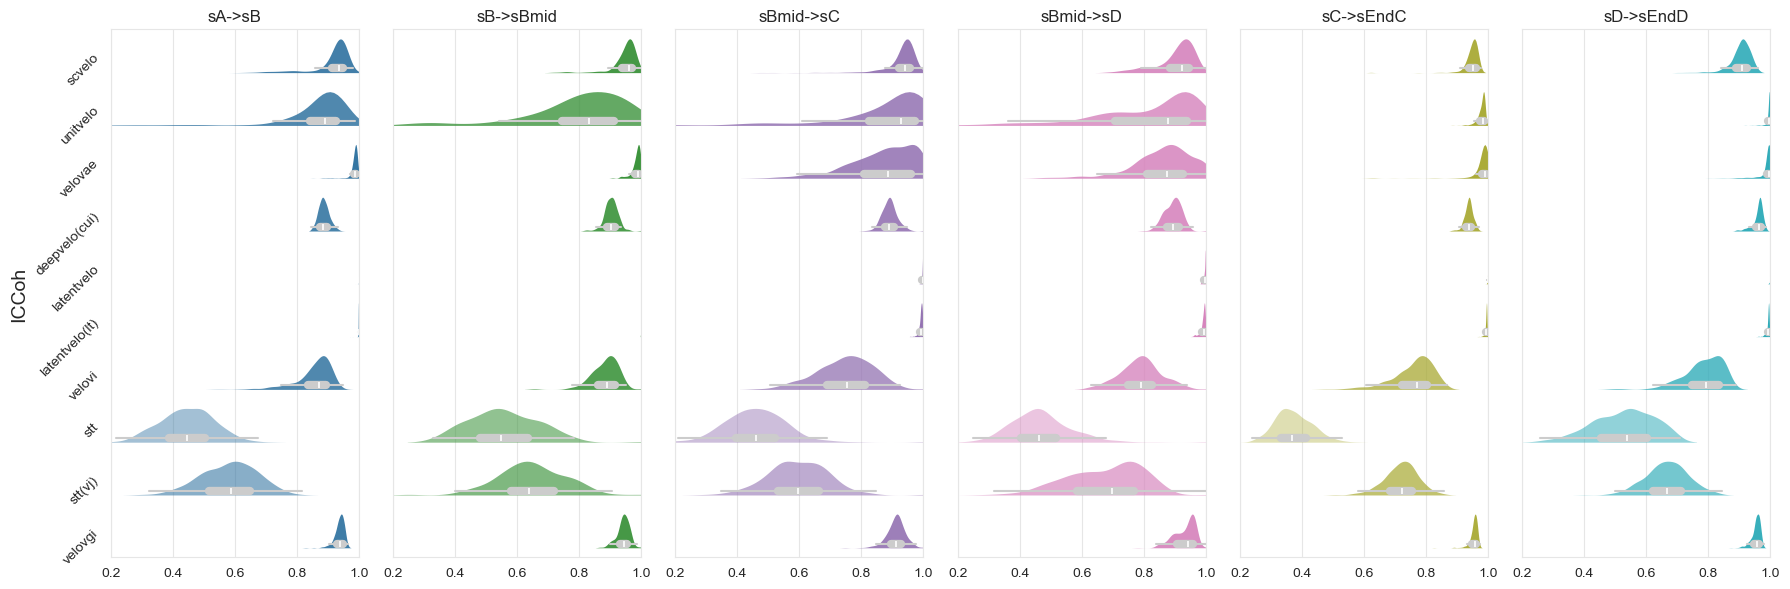

In [42]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    axs[i].set_title(cluster)
    axs[i].set_xlim(0.2, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('ICCoh', fontsize=14)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制k-CBDir

In [7]:
import re
import ast

In [8]:
k = 5
basis = 'umap'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'\s+', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                if model == 'deepvelo_cui':
                    model = 'deepvelo(cui)'
                result[model] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['latentvelo(lt)'] = cbdir
    results[edge] = result
results

{'sA->sB -> sB->sBmid': {'k': range(1, 6),
  'scvelo': [-0.01053543, 0.03974582, 0.31567901, 0.52545543, 0.59342568],
  'unitvelo': [0.04956195, 0.01918298, 0.26174659, 0.48069116, 0.55877695],
  'velovae': [0.27584711, 0.27237074, 0.51516431, 0.68806966, 0.75216798],
  'deepvelo(cui)': [-0.09536757,
   -0.10431237,
   0.15771872,
   0.4181432,
   0.50884886],
  'latentvelo': [0.02435044, 0.05628711, 0.31867583, 0.51737564, 0.58471514],
  'latentvelo(lt)': [0.00759116,
   0.0573677,
   0.32832826,
   0.53180331,
   0.59922934],
  'velovi': [0.12587404, 0.12014919, 0.37844749, 0.5877691, 0.65807324],
  'stt': [0.13086668, 0.15282221, 0.41253021, 0.61109656, 0.68034741],
  'stt(vj)': [0.21447831, 0.24513173, 0.50289923, 0.68739063, 0.75031985],
  'velovgi': [-0.15076017, -0.10875056, 0.16478207, 0.42781267, 0.51517965]},
 'sB->sBmid -> sBmid->sD': {'k': range(1, 6),
  'scvelo': [0.10181334, 0.10635398, 0.38812348, 0.58565126, 0.64124471],
  'unitvelo': [-0.07169191, 0.04626309, 0.2563522

In [6]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovi': plt.cm.Set2(2 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'stt(vj)': plt.cm.Set2(4 / 8),
    'topovelo(KNN)': plt.cm.Set2(6 / 8),
    'topovelo(Delaunay)': plt.cm.Set3(1 / 12),
    'velovae(prior)': plt.cm.Set3(7 / 12),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'latentvelo(prior)': plt.cm.Set3(10 / 12),
    'latentvelo': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)': plt.cm.tab20c(15 / 20),
    'latentvelo(prior)(lt)': plt.cm.Set3(10 / 12),
    'latentvelo(lt)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)(lt)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(lt)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)(lt)': plt.cm.tab20c(15 / 20),
    'velovgi': plt.cm.tab20c(0 / 20),
    'velovgi(batch)': plt.cm.tab20c(3 / 20),
}
line_styles = {
    'scvelo': (1, 0),  # '-' 实线
    'unitvelo': (1, 0),  # '-' 实线
    'velovi': (1, 0),  # '-' 实线
    'velovae': (1, 0),  # '-' 实线
    'stt': (1, 0),  # '-' 实线
    'stt(vj)': (4, 2),  # '--' 虚线
    'topovelo(KNN)': (1, 0),  # '-' 实线
    'topovelo(Delaunay)': (1, 0),  # '-' 实线
    'velovae(prior)': (1, 0),  # '-' 实线
    'deepvelo(cui)': (1, 0),  # '-' 实线
    'latentvelo(prior)': (1, 0),  # '-' 实线
    'latentvelo': (1, 0),  # '-' 实线
    'latentvelo(batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)': (1, 0),  # '-' 实线
    'latentvelo(annot)(batch)': (1, 0),  # '-' 实线
    'latentvelo(prior)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(lt)': (4, 2),  # '--' 虚线
    'latentvelo(batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(batch)(lt)': (4, 2),  # '--' 虚线
    'velovgi': (1, 0),  # '-' 实线
    'velovgi(batch)': (1, 0),  # '-' 实线
}

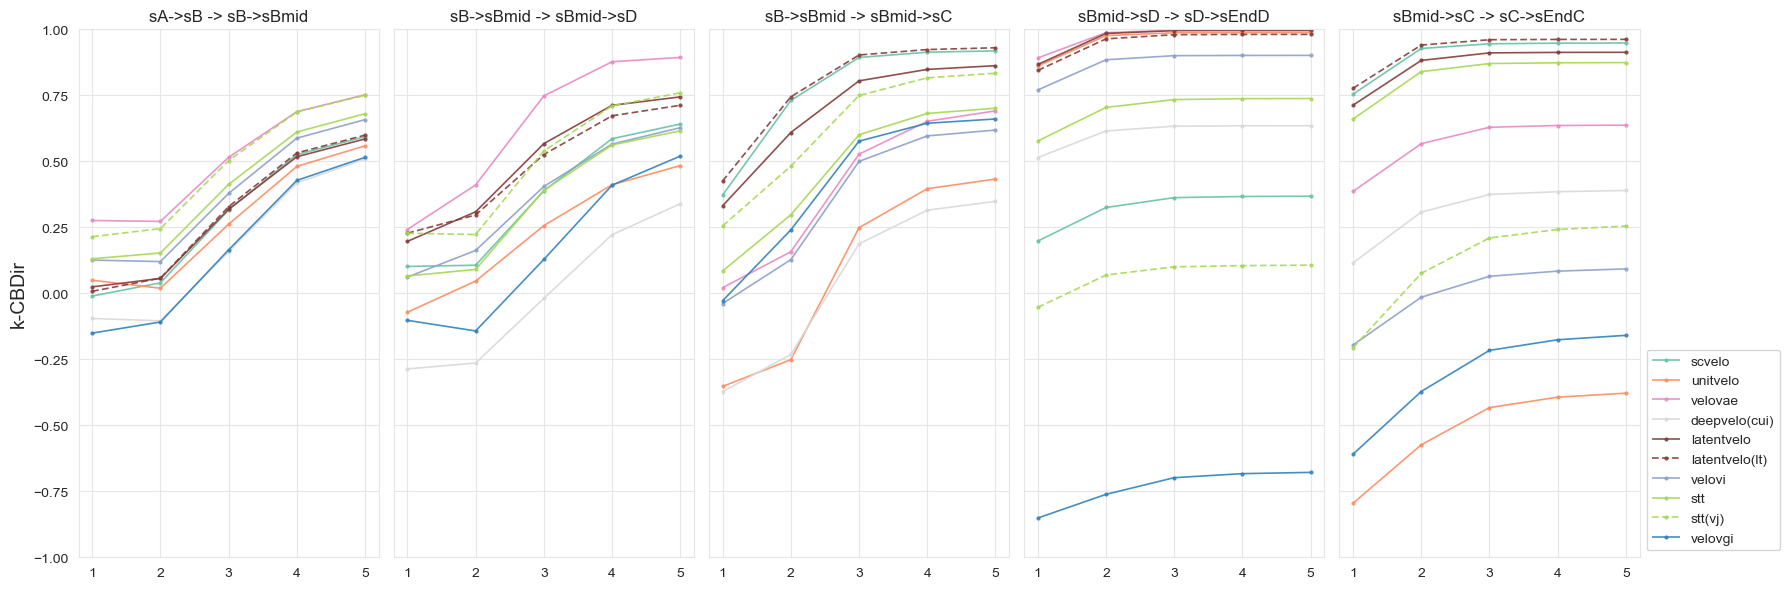

In [19]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors,
        style='model',
        dashes=line_styles, 
        ax=axs[i], 
        linewidth=1.2,
        alpha=0.9,
        markersize=3,
        marker='o',
        markeredgewidth=0,
    )
    axs[i].set_title(edge)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('k-CBDir', fontsize=14)
    axs[i].set_ylim(-1, 1)
    axs[i].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg', bbox_inches='tight')
plt.show()

Time Corr & Velocity Acc

In [6]:
metrics = ['time_corr_spearman', 'velocity_acc']
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for metric_name in metrics:
    result = {}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if metric_name == 'time_corr_spearman':
            if model in ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'topovelo']:
                idx_name = f'{metric_name}_pred_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'].values[0])
                if model == 'deepvelo_cui':
                    model = 'deepvelo(cui)'
                result[model] = t_corr
            if model in ['scvelo', 'velovi', 'velovgi']:
                idx_name = f'{metric_name}_fit_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'].values[0])
                result[f'{model}(avg)' if model == 'scvelo' else model] = t_corr
        if metric_name == 'velocity_acc':
            idx_name = f'{metric_name}_{model_name}_velocity'
            v_acc = float(metric.loc[metric.index == idx_name, '0'].values[0])
            if model == 'deepvelo_cui':
                model = 'deepvelo(cui)'
            result[model] = v_acc
            if model == 'latentvelo':
                ltv_idx_name = f'{metric_name}_latent_velocity'
                v_acc = float(metric.loc[metric.index == ltv_idx_name, '0'].values[0])
                result['latentvelo(lt)'] = v_acc
    results[metric_name] = result
results

{'time_corr_spearman': {'scvelo': 0.8165652123672289,
  'scvelo(avg)': 0.7071417933353481,
  'unitvelo': -0.009990649414795563,
  'velovae': 0.6889789861493537,
  'deepvelo(cui)': 0.6137413831611722,
  'latentvelo': 0.8644175038973667,
  'velovi': 0.4882159668839772,
  'velovgi': 0.6781872235357471},
 'velocity_acc': {'scvelo': 0.05621124994009752,
  'unitvelo': 0.008425417665995428,
  'velovae': 0.01593238668319226,
  'deepvelo(cui)': 0.042146135917729616,
  'latentvelo': 0.017053165749221416,
  'latentvelo(lt)': 0.207171263730317,
  'velovi': 0.049464184943510126,
  'stt': 0.12388312299414925,
  'velovgi': 0.025830641464177243}}

In [7]:
color_maps = [plt.cm.Blues, plt.cm.Greens]

In [8]:
models_total = ['scvelo', 'scvelo(avg)', 'unitvelo', 'velovae', 'deepvelo(cui)', 'latentvelo', 'latentvelo(lt)', 'velovi', 'stt', 'velovgi']

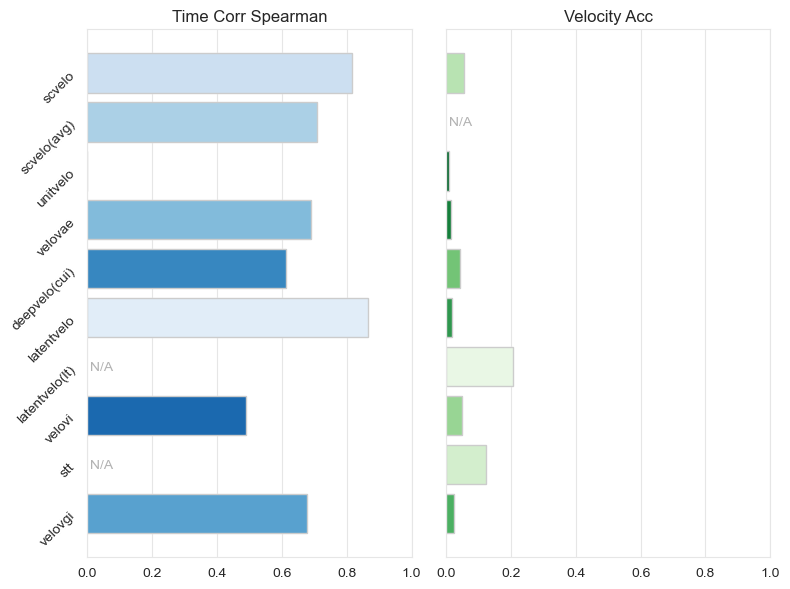

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(8, 6))
for i, (metric_name, result) in enumerate(results.items()):
    result_sorted = {model: result.get(model, float('nan')) for model in models_total}
    df = pd.DataFrame(list(result_sorted.items()), columns=['model', metric_name])
    color_map = color_maps[i]
    sns.barplot(data=df, x=metric_name, y='model', ax=axs[i], orient='h')
    df['rank'] = df[metric_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric_name], df['rank'])):
        if pd.isna(value):
            axs[i].text(x=0.01, y=j, s='N/A', ha='left', va='center', fontsize=10, color='.7')
        else:
            axs[i].barh(model, value, color=color_map(rank / (len(result) + 1)), edgecolor='.8', linewidth=1)
    axs[i].set_title(metric_name.replace('_', ' ').title())
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_xlim(0, 1)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(results.keys())}.svg', bbox_inches='tight')
plt.show()